In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [16]:

df = pd.read_csv("driver_behavior.csv")

print(df.head())

   speed_kmph   accel_x   accel_y  brake_pressure  steering_angle  throttle  \
0   -1.646197 -0.677689  1.264479       -0.605615       -0.333874 -0.029914   
1   -1.502903 -0.228698 -1.078528       -0.084025       -2.575153 -0.817606   
2    0.859157  2.502836  1.549250        1.526413       -0.643518  1.145865   
3    1.937781  1.275730 -1.096786        0.218909        1.891133  1.366293   
4   -0.455938 -1.433722  0.742446       -0.016311       -0.432609  0.361065   

   lane_deviation  phone_usage  headway_distance  reaction_time  \
0        0.756130     1.414866         -0.503335       0.850947   
1        2.271441     1.414866          0.479102       0.912802   
2       -0.733058    -0.706781         -1.070117      -1.305385   
3        0.905243    -0.706781         -1.075191      -1.016568   
4        2.600000     1.414866         -0.175677       0.785500   

  behavior_label  behavior_label_encoded  
0     Distracted                       1  
1     Distracted                    

In [17]:
le = LabelEncoder()

df['behavior_label_encoded'] = le.fit_transform(df['behavior_label'])

print("\nEncoded Classes:")
print(dict(zip(le.classes_, le.transform(le.classes_))))


Encoded Classes:
{'Aggressive': np.int64(0), 'Distracted': np.int64(1), 'Safe': np.int64(2)}


In [18]:
X = df[[
    'speed_kmph',
    'accel_x',
    'accel_y',
    'brake_pressure',
    'steering_angle',
    'throttle',
    'lane_deviation',
    'phone_usage',
    'headway_distance',
    'reaction_time'
]]

y = df['behavior_label_encoded']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (22124, 10)
Testing Shape: (5532, 10)


In [20]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nRandom Forest Model Trained Successfully!")


Random Forest Model Trained Successfully!


In [21]:
y_pred = model.predict(X_test)

print("\nPredicted Values:")
print(y_pred[:10])


Predicted Values:
[1. 0. 2. 0. 1. 0. 1. 2. 0. 1.]


In [22]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n===== MODEL EVALUATION =====")

print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R2 Score:", r2)


===== MODEL EVALUATION =====
Mean Absolute Error (MAE): 0.00014461315979754158
Mean Squared Error (MSE): 0.00011569052783803329
Root Mean Squared Error (RMSE): 0.0107559531348009
R2 Score: 0.9998257425376115


In [23]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("\nActual vs Predicted:")
print(comparison.head(10))


Actual vs Predicted:
   Actual  Predicted
0       1        1.0
1       0        0.0
2       2        2.0
3       0        0.0
4       1        1.0
5       0        0.0
6       1        1.0
7       2        2.0
8       0        0.0
9       1        1.0


In [24]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)


Feature Importance:
            Feature  Importance
9     reaction_time    0.892581
7       phone_usage    0.107419
1           accel_x    0.000000
0        speed_kmph    0.000000
2           accel_y    0.000000
3    brake_pressure    0.000000
5          throttle    0.000000
4    steering_angle    0.000000
6    lane_deviation    0.000000
8  headway_distance    0.000000


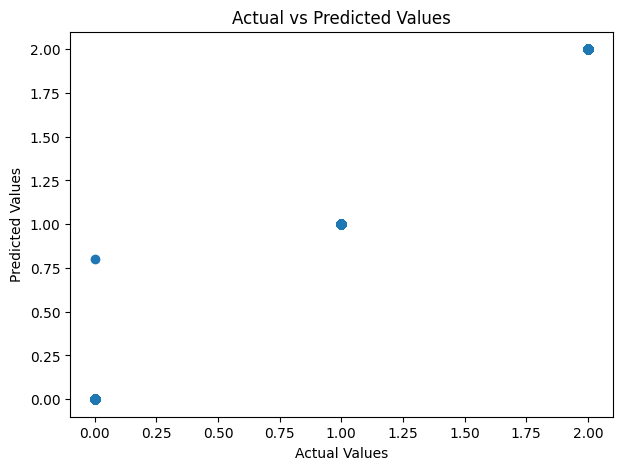

In [25]:

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()



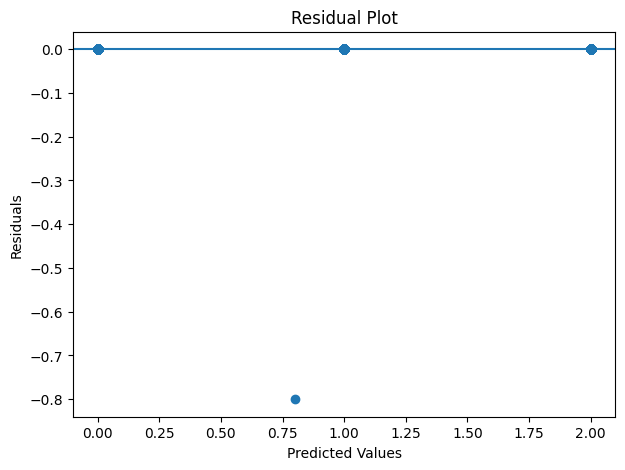

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

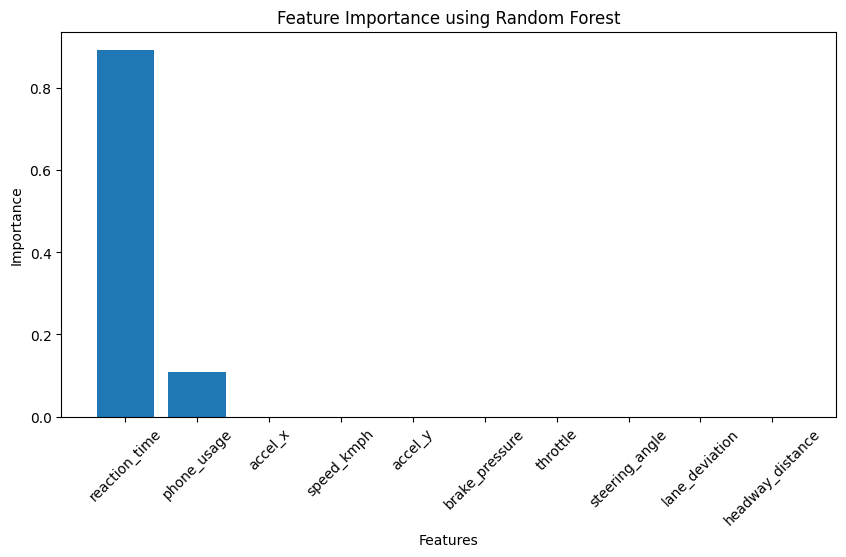

In [27]:
plt.figure(figsize=(10,5))

plt.bar(importance['Feature'], importance['Importance'])

plt.xticks(rotation=45)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Feature Importance using Random Forest")

plt.show()
 

In [28]:
sample_data = [[
    36.07,     # speed_kmph
    0.53,      # accel_x
    0.70,      # accel_y
    23.10,     # brake_pressure
    -3.16,     # steering_angle
    53.12,     # throttle
    0.85,      # lane_deviation
    1,         # phone_usage
    17.99,     # headway_distance
    1.40       # reaction_time
]]

prediction = model.predict(sample_data)

print("\nPredicted Encoded Behavior:")
print(prediction)


Predicted Encoded Behavior:
[1.]


c:\Users\rithi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [29]:
comparison.to_csv("non_linear_regression_predictions.csv", index=False)

print("\nPredictions saved successfully!")


Predictions saved successfully!
